In [141]:
!pip install nltk wordcloud

In [142]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Regular Expressions
import re

# String Operations
import string

# Natural Language Processing
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Word Cloud
from wordcloud import WordCloud

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import LinearSVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [143]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [144]:
fake = pd.read_csv("Fake.csv.zip")
true = pd.read_csv("True.csv.zip")

In [145]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [146]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [147]:
fake.shape

(23481, 4)

In [148]:
true.shape

(21417, 4)

In [149]:
fake.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [150]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [151]:
true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [152]:
fake.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [153]:
true.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [154]:
fake.describe(include="all")

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


In [155]:
true.describe(include="all")

,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


In [156]:
fake["label"] = 0
true["label"] = 1

In [157]:
data = pd.concat([fake, true], ignore_index=True)

In [158]:
data = data.sample(frac=1, random_state=42)

In [159]:
data.reset_index(drop=True, inplace=True)

In [160]:
data["label"].value_counts()

,count
label,
0,23481
1,21417


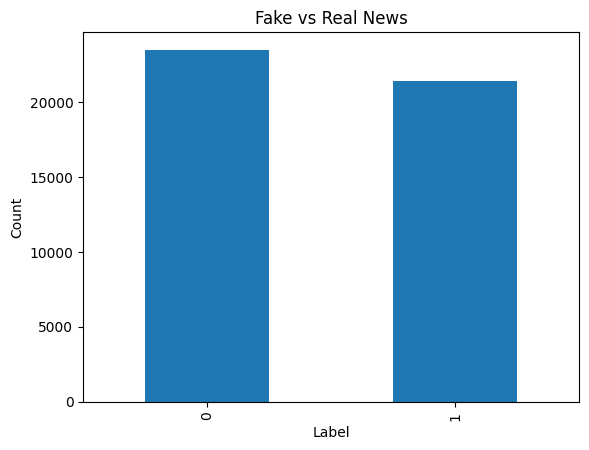

In [161]:
data["label"].value_counts().plot(kind="bar")

plt.title("Fake vs Real News")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

In [162]:
data["text_length"] = data["text"].apply(len)

In [163]:
data[["text", "text_length"]].head()

,text,text_length
0,"21st Century Wire says Ben Stein, reputable pr...",1028
1,WASHINGTON (Reuters) - U.S. President Donald T...,4820
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1848
3,"On Monday, Donald Trump once again embarrassed...",1244
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",3137


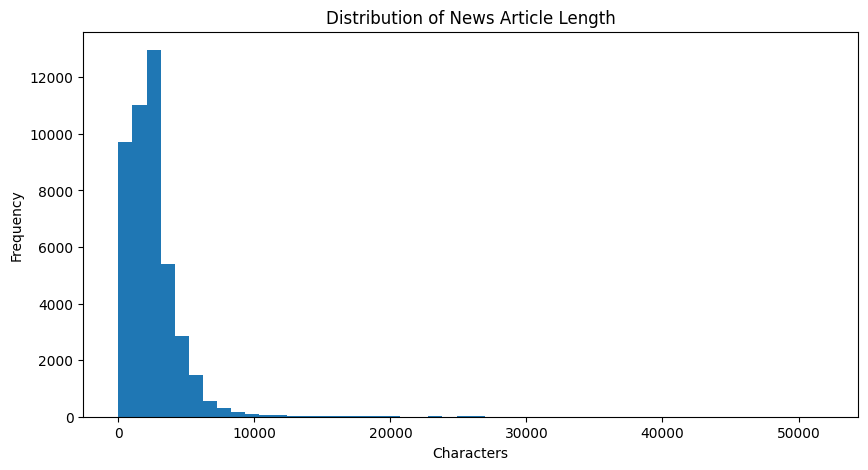

In [164]:
plt.figure(figsize=(10,5))

plt.hist(data["text_length"], bins=50)

plt.title("Distribution of News Article Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [165]:
data["text"] = data["text"].str.lower()
print(data["text"][0])

21st century wire says ben stein, reputable professor from, pepperdine university (also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off) made some provocative statements on judge jeanine pirro s show recently. while discussing the halt that was imposed on president trump s executive order on travel. stein referred to the judgement by the 9th circuit court in washington state as a  coup d tat against the executive branch and against the constitution.  stein went on to call the judges in seattle  political puppets  and the judiciary  political pawns. watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the executive order.read more trump news at: 21st century wire trump filessupport our work by subscribing & 

In [166]:
def remove_url(text):
    return re.sub(r"http\S+|www\S+|https\S+", "", text)
def remove_html(text):
    return re.sub(r"<.*?>", "", text)
def remove_punctuation(text):

    return text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )
def remove_numbers(text):
    return re.sub(r"\d+", "", text)
def remove_spaces(text):
    return " ".join(text.split())
stop_words = set(stopwords.words("english"))
def remove_stopwords(text):

    words = text.split()

    filtered = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(filtered)
lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)
def clean_text(text):

    text = text.lower()

    text = remove_url(text)

    text = remove_html(text)

    text = remove_punctuation(text)

    text = remove_numbers(text)

    text = remove_spaces(text)

    text = remove_stopwords(text)

    text = lemmatize_text(text)

    return text
data["clean_text"] = data["text"].apply(clean_text)

In [167]:
print("Original News:\n")
print(data["text"][5])

print("\n")

print("Clean News:\n")
print(data["clean_text"][5])

Original News:

on wednesday, democrats took a powerful stance against the gop s refusal to vote on gun control measures by staging a sit-in. while republican politicians called a recess and took a lunch break, dems stayed put on the floor and fought for the safety of america s citizens.hours after the sit-in, house speaker paul ryan weighed in on the event in an interview with cnn, and his comments were just as disappointing as they were disgusting. his response to a sit-in, which follows the deaths of almost 50 innocent americans that lost their lives in a tragic mass shooting in orlando a week ago, was this brutal sentence: this is nothing more than a publicity stunt. seriously   a genuine attempt to get congress to support gun control measures that will protect american citizens from senseless gun violence like mass shootings is considered a  publicity stunt  by a leading republican. the speaker of the house added that the democrats involved in the sit-in were trying to rob america

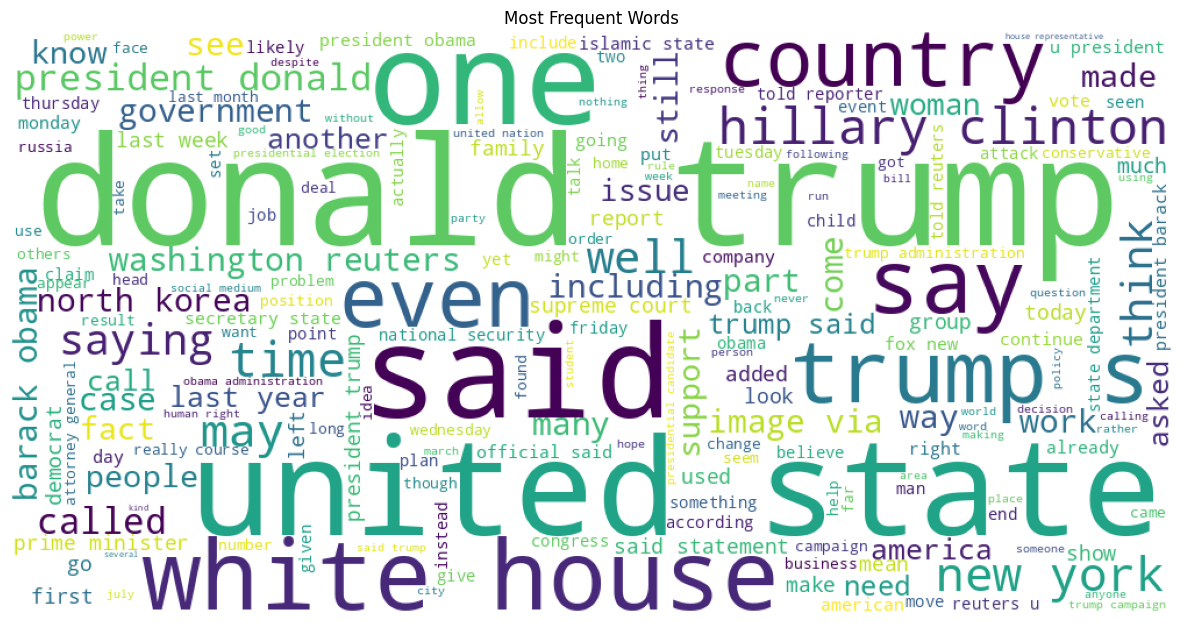

In [168]:
text = " ".join(data["clean_text"])
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)
plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words")

plt.show()

In [169]:
X = data["clean_text"]
y = data["label"]
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)


In [170]:
vectorizer = TfidfVectorizer(

    max_features=5000,

    stop_words="english"

)
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)
print(X_train_vectorized.shape)

print(X_test_vectorized.shape)

(35918, 5000)
(8980, 5000)


Accuracy : 0.9865256124721603
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4696
           1       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

[[4618   78]
 [  43 4241]]


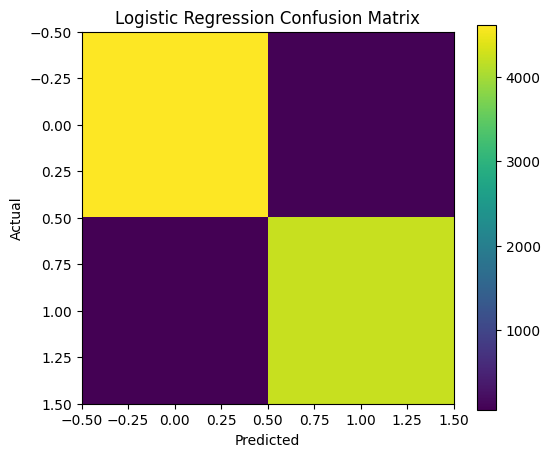

In [171]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_vectorized, y_train)
lr_prediction = lr.predict(X_test_vectorized)
lr_accuracy = accuracy_score(
    y_test,
    lr_prediction
)

print("Accuracy :", lr_accuracy)
print(classification_report(
    y_test,
    lr_prediction
))
cm = confusion_matrix(
    y_test,
    lr_prediction
)

print(cm)
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Logistic Regression Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [172]:
nb = MultinomialNB()

nb.fit(
    X_train_vectorized,
    y_train
)
nb_prediction = nb.predict(
    X_test_vectorized
)
nb_accuracy = accuracy_score(
    y_test,
    nb_prediction
)

print(nb_accuracy)


0.9321826280623609


In [173]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(
    X_train_vectorized,
    y_train
)
rf_prediction = rf.predict(
    X_test_vectorized
)
rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

print(rf_accuracy)


0.9978841870824053


In [174]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [175]:
svm = LinearSVC()

svm.fit(
    X_train_vectorized,
    y_train
)
svm_prediction = svm.predict(
    X_test_vectorized
)
svm_accuracy = accuracy_score(
    y_test,
    svm_prediction
)

print(svm_accuracy)


0.993652561247216


In [176]:
models = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Naive Bayes",

        "Random Forest",

        "Linear SVM"

    ],

    "Accuracy":[

        lr_accuracy,

        nb_accuracy,

        rf_accuracy,

        svm_accuracy

    ]

})

models

,Model,Accuracy
0,Logistic Regression,0.986526
1,Naive Bayes,0.932183
2,Random Forest,0.997884
3,Linear SVM,0.993653


In [177]:
best_model = models.loc[
    models["Accuracy"].idxmax()
]

print(best_model)

Model       Random Forest
Accuracy         0.997884
Name: 2, dtype: object


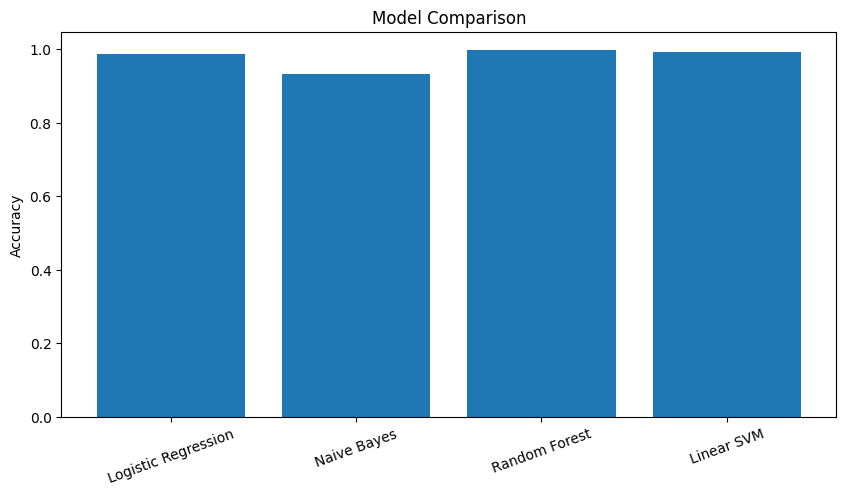

In [178]:
plt.figure(figsize=(10,5))

plt.bar(

    models["Model"],

    models["Accuracy"]

)

plt.xticks(rotation=20)

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.show()

In [179]:
news = [

"""Scientists discovered water on Mars."""

]

news_vector = vectorizer.transform(news)

prediction = svm.predict(news_vector)

print(prediction)

[0]


In [180]:

if prediction[0]==0:

    print("Fake News")

else:

    print("Real News")

Fake News


In [181]:
import pickle
pickle.dump(

    svm,

    open(

        "truthlens_model.pkl",

        "wb"

    )

)
pickle.dump(

    vectorizer,

    open(

        "vectorizer.pkl",

        "wb"

    )

)

In [182]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_vectorized, y_train)
probability = lr.predict_proba(news_vector)
confidence = max(probability[0]) * 100

print(confidence)

95.66484450110818


In [183]:
nltk.download("vader_lexicon")
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
def get_sentiment(text):

    score = sia.polarity_scores(text)

    compound = score["compound"]

    if compound >= 0.05:
        return "Positive"

    elif compound <= -0.05:
        return "Negative"

    else:
        return "Neutral"
news = """
Scientists discovered water on Mars.
"""

print(get_sentiment(news))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Neutral


In [184]:
def calculate_trust_score(prediction,
                          confidence,
                          sentiment):

    score = 100

    if prediction == "Fake":
        score -= 60

    else:
        score += 0

    if sentiment == "Negative":
        score -= 15

    elif sentiment == "Neutral":
        score += 10

    else:
        score += 5

    if confidence < 80:
        score -= 10

    else:
        score += 5

    score = max(0, min(score, 100))

    return score

In [185]:
def risk_level(score):

    if score >= 80:
        return "Low"

    elif score >= 50:
        return "Medium"

    else:
        return "High"

In [186]:
def recommendation(score):

    if score >= 80:

        return (
            "Content appears trustworthy. "
            "Still verify important claims."
        )

    elif score >= 50:

        return (
            "Exercise caution. "
            "Cross-check with reliable news sources."
        )

    else:

        return (
            "High misinformation risk. "
            "Do not share until verified."
        )

In [187]:
def explain(prediction,
            confidence,
            sentiment):

    reasons = []

    if prediction == "Fake":

        reasons.append(
            "Model classified the article as Fake."
        )

    else:

        reasons.append(
            "Model classified the article as Real."
        )

    if confidence > 95:

        reasons.append(
            "Prediction confidence is very high."
        )

    elif confidence > 80:

        reasons.append(
            "Prediction confidence is high."
        )

    else:

        reasons.append(
            "Prediction confidence is moderate."
        )

    if sentiment == "Negative":

        reasons.append(
            "Emotionally negative language detected."
        )

    elif sentiment == "Positive":

        reasons.append(
            "Positive emotional tone detected."
        )

    else:

        reasons.append(
            "Neutral language detected."
        )

    return reasons

In [188]:
def analyze_news(news):

    cleaned = clean_text(news)

    vector = vectorizer.transform([cleaned])

    prediction = lr.predict(vector)[0]

    probability = lr.predict_proba(vector)

    confidence = max(probability[0]) * 100

    if prediction == 0:
        prediction = "Fake"
    else:
        prediction = "Real"

    sentiment = get_sentiment(news)

    trust = calculate_trust_score(
        prediction,
        confidence,
        sentiment
    )

    risk = risk_level(trust)

    advice = recommendation(trust)

    reasons = explain(
        prediction,
        confidence,
        sentiment
    )

    print("=" * 60)
    print("TruthLens AI Report")
    print("=" * 60)

    print(f"Prediction     : {prediction}")
    print(f"Confidence     : {confidence:.2f}%")
    print(f"Sentiment      : {sentiment}")
    print(f"Trust Score    : {trust}/100")
    print(f"Risk Level     : {risk}")

    print("\nWhy?")
    for r in reasons:
        print("•", r)

    print("\nRecommendation")
    print(advice)

In [189]:
news = """
Breaking!

Government gives every student
₹50,000 tomorrow.

Click below immediately.

Limited offer.
"""

analyze_news(news)

TruthLens AI Report
Prediction     : Fake
Confidence     : 87.24%
Sentiment      : Negative
Trust Score    : 30/100
Risk Level     : High

Why?
• Model classified the article as Fake.
• Prediction confidence is high.
• Emotionally negative language detected.

Recommendation
High misinformation risk. Do not share until verified.
